# Laboratorio 10 — Aprendizaje Semi-Supervisado
**CC3074 Minería de Datos | UVG Semestre I – 2026**

**Dataset:** Dry Bean Dataset — Koklu & Ozkan (2020)  
**Fuente:** https://archive.ics.uci.edu/dataset/602/dry+bean+dataset  


## 1. Importacion inicial de datos

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('Results', exist_ok=True)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

df = pd.read_excel('DryBeanDataset/Dry_Bean_Dataset.xlsx')

print('Shape:', df.shape)
print('\nColumnas:', df.columns.tolist())
df.head()

Shape: (13611, 17)

Columnas: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [2]:
print('Tipos de datos:')
print(df.dtypes)
print('\nValores nulos por columna:')
print(df.isnull().sum())
print('\nDuplicados:', df.duplicated().sum())

Tipos de datos:
Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object

Valores nulos por columna:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Duplicados: 68


## 2. Inspeccion del conjunto de datos

El dataset contiene mediciones morfologicas de 13,611 granos de frijol obtenidas mediante
vision por computadora. Se clasifican en 7 variedades: SEKER, BARBUNYA, BOMBAY, CALI,
HOROZ, SIRA y DERMASON. Las 16 variables son completamente numericas (areas, perimetros,
factores de forma), lo que lo hace ideal para algoritmos semi-supervisados basados en
distancia y grafos.

In [3]:
# Estadisticas descriptivas
df.describe().round(4)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000
mean,53048.2845,855.2835,320.1419,202.2707,1.5832,0.7509,53768.2002,253.0642,0.7497,0.9871,0.8733,0.7999,0.0066,0.0017,0.6436,0.9951
std,29324.0957,214.2897,85.6942,44.9701,0.2467,0.0920,29774.9158,59.1771,0.0491,0.0047,0.0595,0.0617,0.0011,0.0006,0.0990,0.0044
min,20420.0000,524.7360,183.6012,122.5127,1.0249,0.2190,20684.0000,161.2438,0.5553,0.9192,0.4896,0.6406,0.0028,0.0006,0.4103,0.9477
25%,36328.0000,703.5235,253.3036,175.8482,1.4323,0.7159,36714.5000,215.0680,0.7186,0.9857,0.8321,0.7625,0.0059,0.0012,0.5814,0.9937
50%,44652.0000,794.9410,296.8834,192.4317,1.5511,0.7644,45178.0000,238.4380,0.7599,0.9883,0.8832,0.8013,0.0066,0.0017,0.6420,0.9964
75%,61332.0000,977.2130,376.4950,217.0317,1.7071,0.8105,62294.0000,279.4465,0.7869,0.9900,0.9169,0.8343,0.0073,0.0022,0.6960,0.9979
max,254616.0000,1985.3700,738.8602,460.1985,2.4303,0.9114,263261.0000,569.3744,0.8662,0.9947,0.9907,0.9873,0.0105,0.0037,0.9748,0.9997


Distribucion de clases:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Clase mas frecuente: DERMASON (3546 muestras)
Clase menos frecuente: BOMBAY (522 muestras)
Ratio desbalance: 6.79x


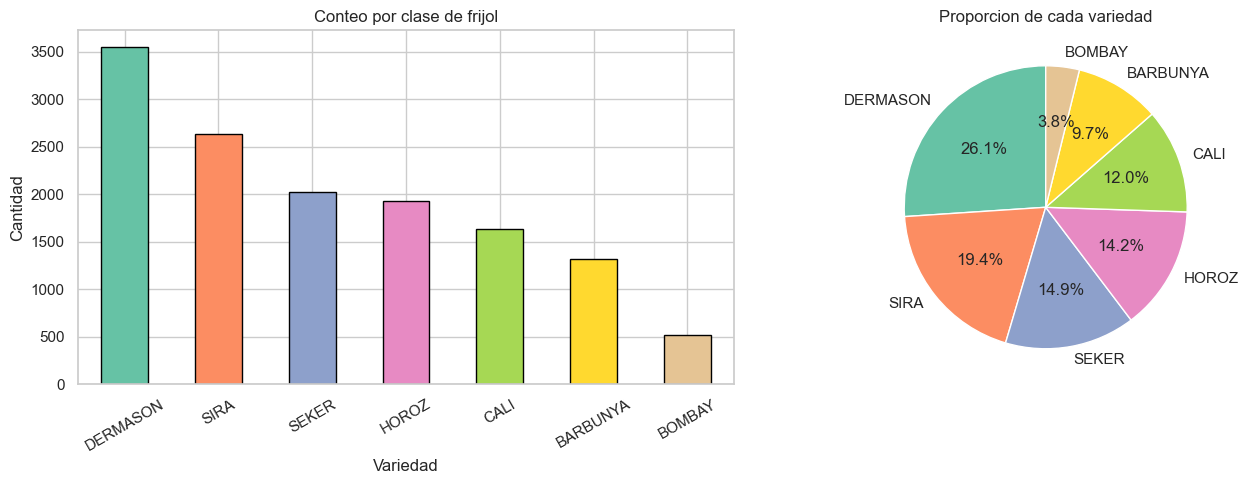

In [4]:
# Balance de clases
class_counts = df['Class'].value_counts()
print('Distribucion de clases:')
print(class_counts)
print(f'\nClase mas frecuente: {class_counts.idxmax()} ({class_counts.max()} muestras)')
print(f'Clase menos frecuente: {class_counts.idxmin()} ({class_counts.min()} muestras)')
print(f'Ratio desbalance: {class_counts.max() / class_counts.min():.2f}x')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', 7), edgecolor='black')
axes[0].set_title('Conteo por clase de frijol')
axes[0].set_xlabel('Variedad')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=30)

class_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                  colors=sns.color_palette('Set2', 7), startangle=90)
axes[1].set_title('Proporcion de cada variedad')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

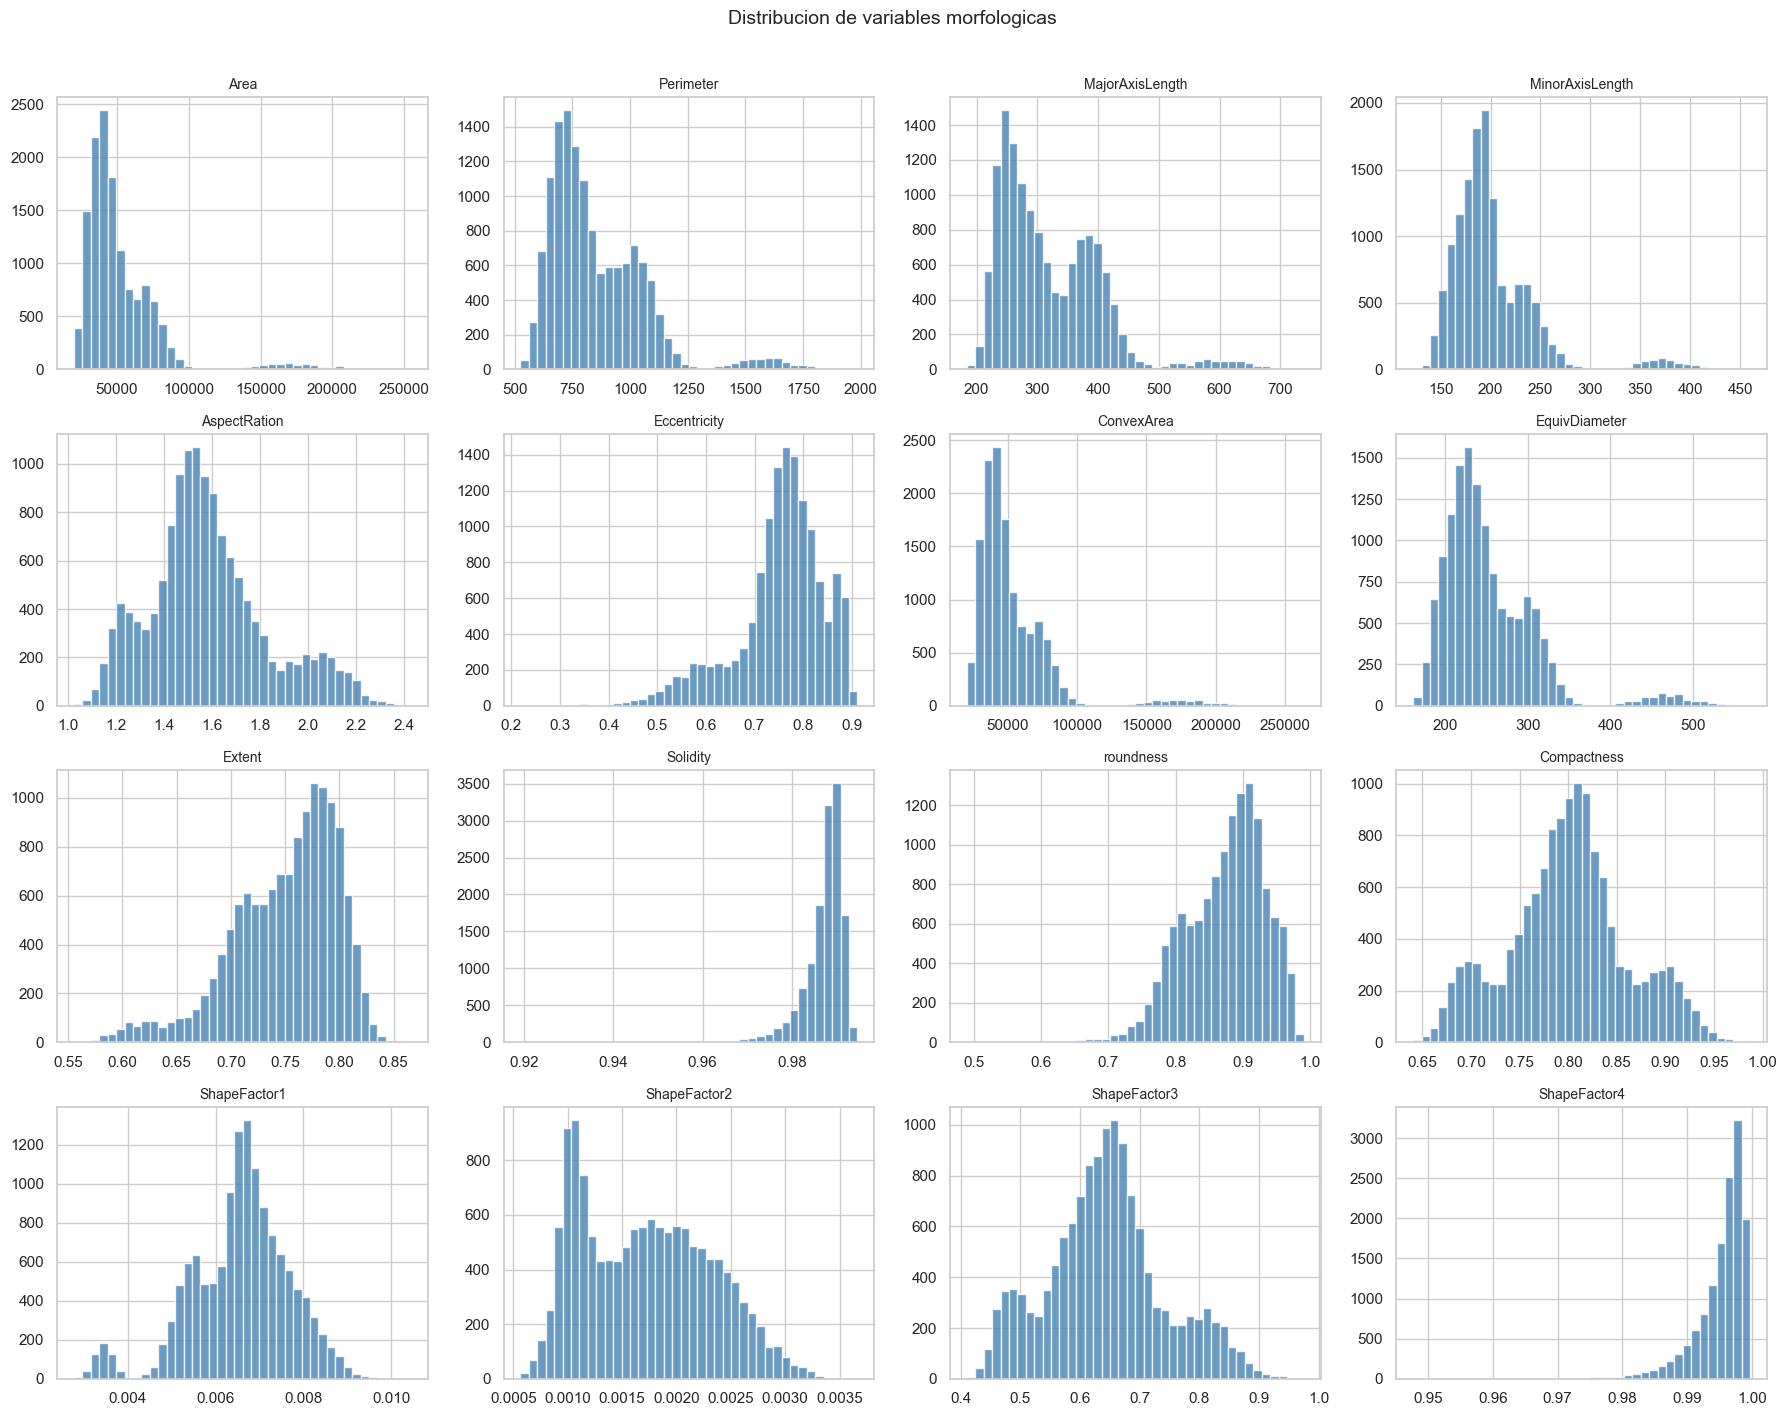

In [5]:
# Distribuciones de todas las variables numericas
features = df.drop(columns=['Class'])
n_cols = 4
n_rows = int(np.ceil(len(features.columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(features.columns):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribucion de variables morfologicas', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

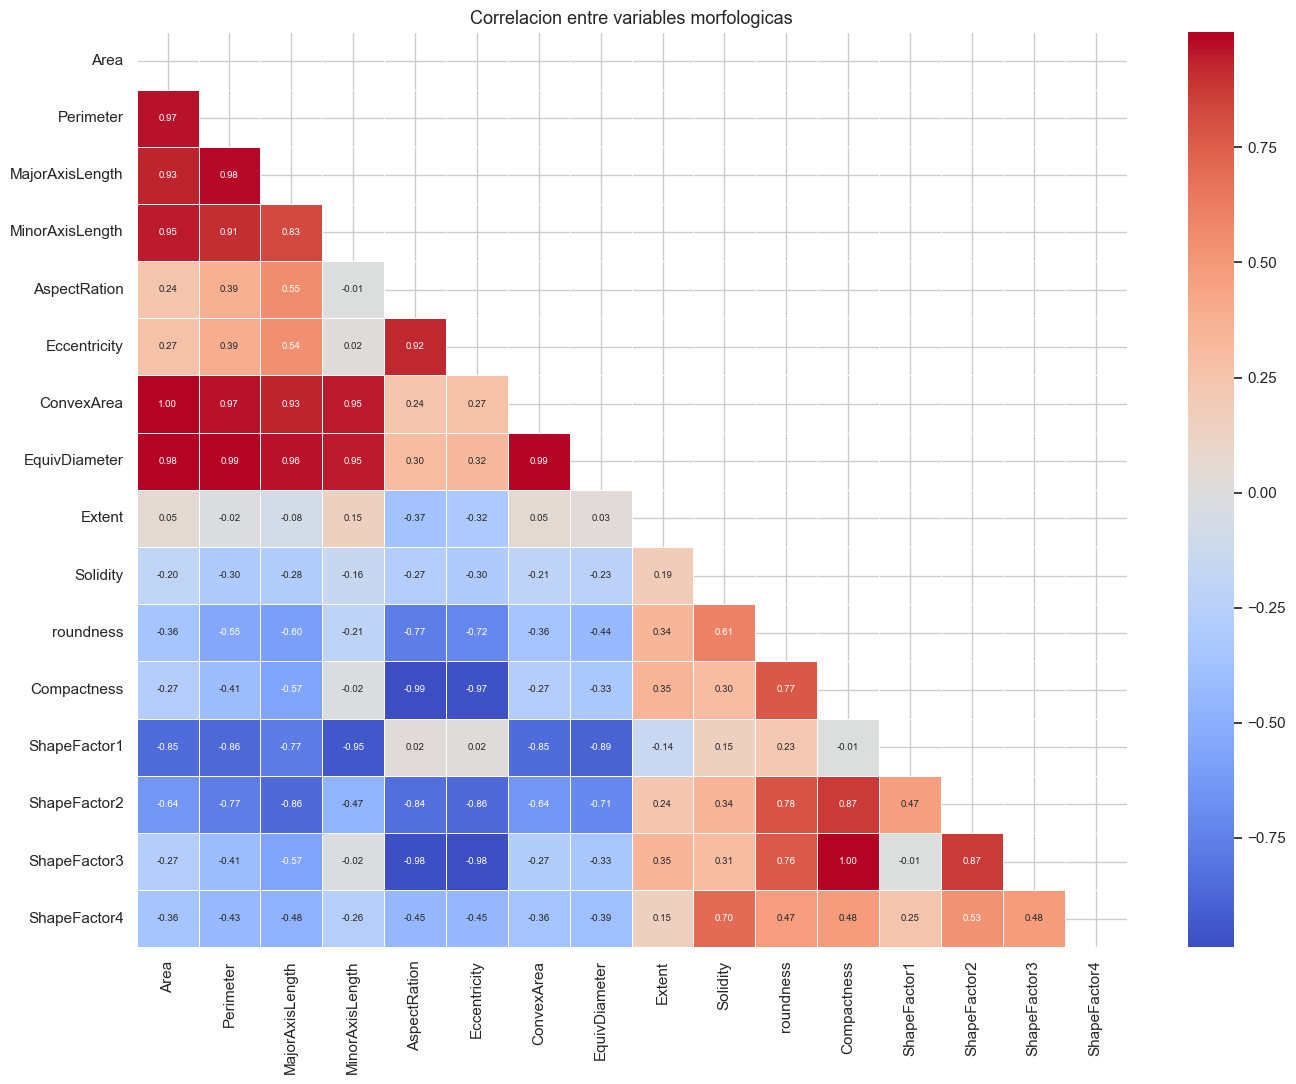

Pares con correlacion > 0.95:
  Area — Perimeter: 0.967
  Area — MinorAxisLength: 0.952
  Area — ConvexArea: 1.0
  Area — EquivDiameter: 0.985
  Perimeter — MajorAxisLength: 0.977
  Perimeter — ConvexArea: 0.968
  Perimeter — EquivDiameter: 0.991
  MajorAxisLength — EquivDiameter: 0.962
  MinorAxisLength — ConvexArea: 0.951
  AspectRation — Compactness: -0.988
  AspectRation — ShapeFactor3: -0.979
  Eccentricity — Compactness: -0.97
  Eccentricity — ShapeFactor3: -0.981
  ConvexArea — EquivDiameter: 0.985
  Compactness — ShapeFactor3: 0.999


In [6]:
# Mapa de correlacion entre features
plt.figure(figsize=(14, 11))
corr = features.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlacion entre variables morfologicas', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Pares con alta correlacion (>0.95)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.95:
            high_corr.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)))

print('Pares con correlacion > 0.95:')
for a, b, c in high_corr:
    print(f'  {a} — {b}: {c}')

C:\Users\jfmar\AppData\Local\Temp\ipykernel_13176\125891712.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=df, ax=axes[i], palette=palette)
C:\Users\jfmar\AppData\Local\Temp\ipykernel_13176\125891712.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=df, ax=axes[i], palette=palette)
C:\Users\jfmar\AppData\Local\Temp\ipykernel_13176\125891712.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=df, ax=axes[i], palette=palette)
C:\Users\jfmar\AppData\Local\Temp\ipyker

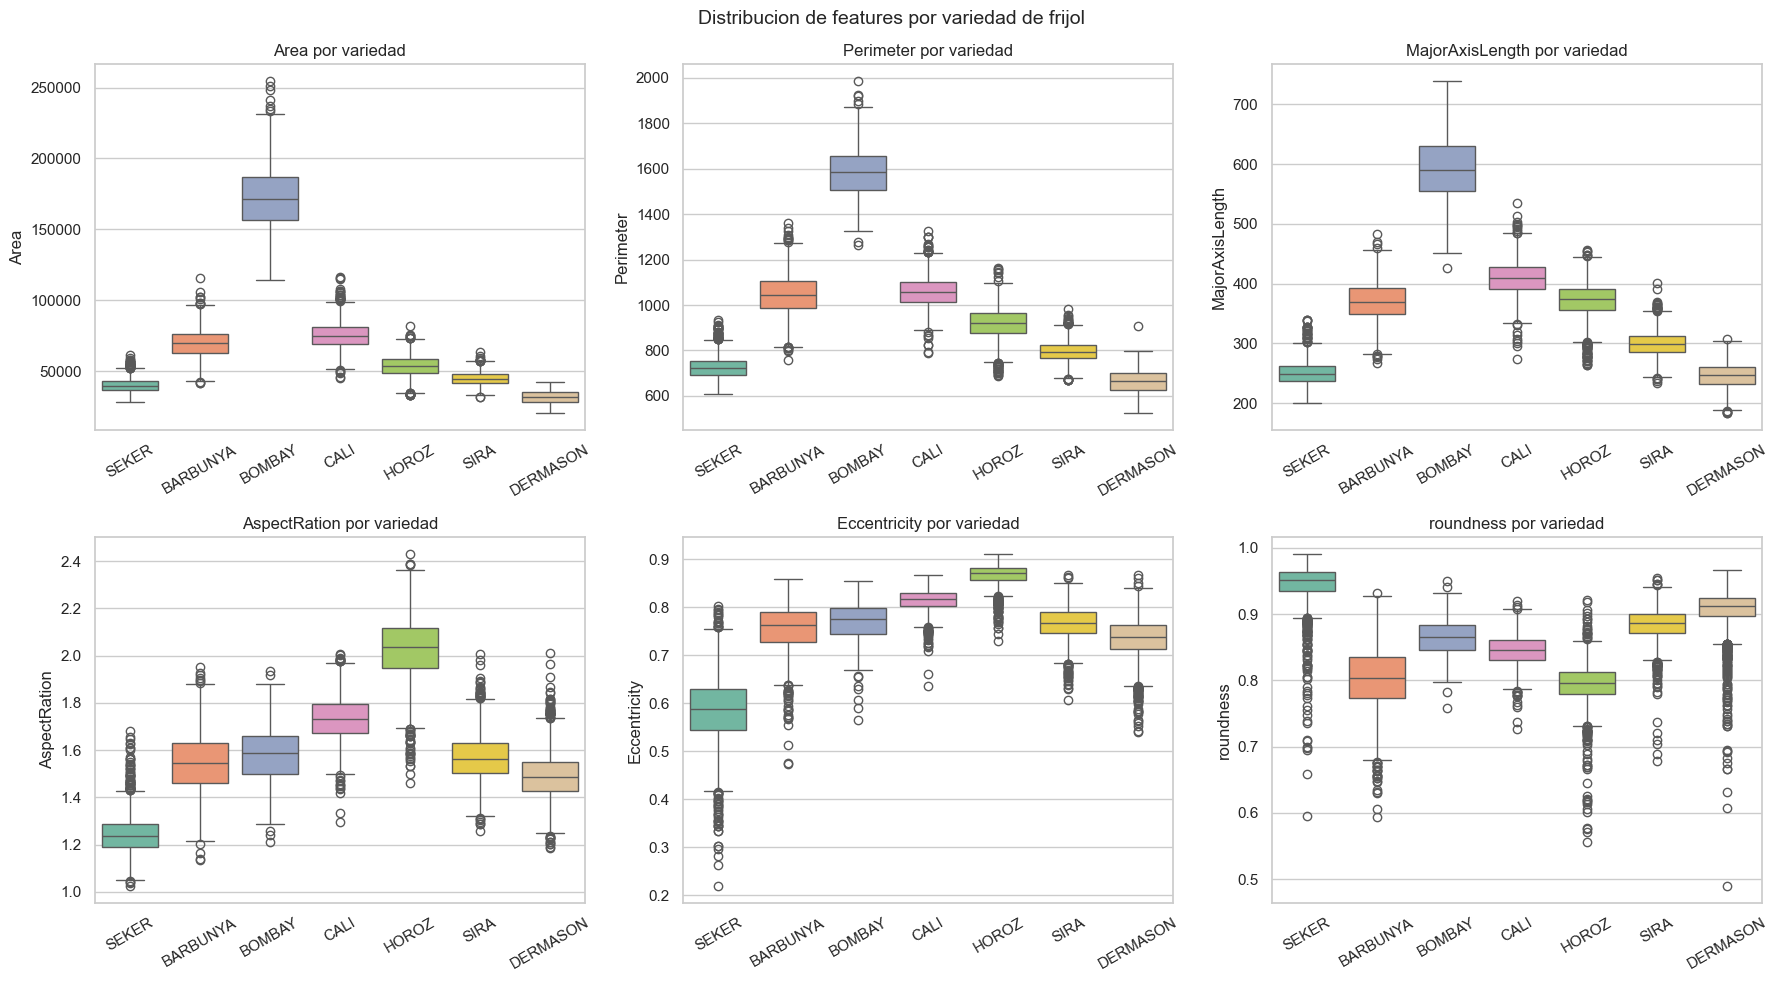

In [7]:
# Boxplots de features clave por variedad de frijol
key_features = ['Area', 'Perimeter', 'MajorAxisLength', 'AspectRation', 'Eccentricity', 'roundness']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
palette = sns.color_palette('Set2', 7)

for i, feat in enumerate(key_features):
    sns.boxplot(x='Class', y=feat, data=df, ax=axes[i], palette=palette)
    axes[i].set_title(f'{feat} por variedad')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Distribucion de features por variedad de frijol', fontsize=14)
plt.tight_layout()
plt.savefig('boxplots_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

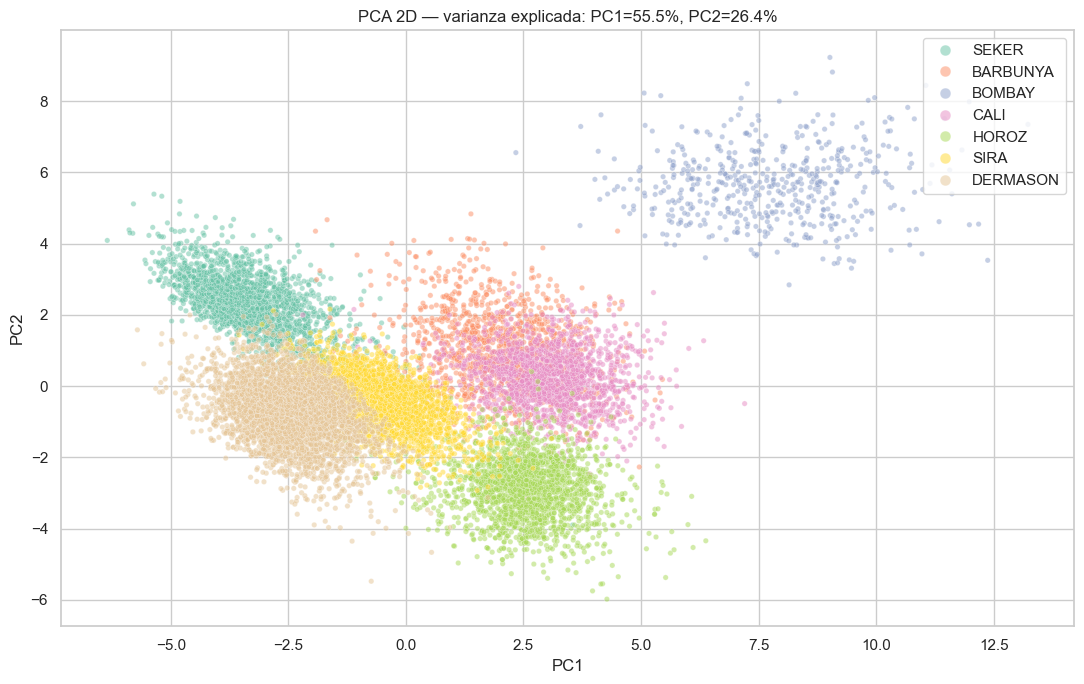

In [8]:
# Visualizacion PCA 2D para entender la separabilidad entre clases
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_temp = StandardScaler().fit_transform(features)
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_temp)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Class'] = df['Class'].values

plt.figure(figsize=(11, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Class',
                palette='Set2', alpha=0.5, s=15)
plt.title(f'PCA 2D — varianza explicada: PC1={pca_2d.explained_variance_ratio_[0]*100:.1f}%, '
          f'PC2={pca_2d.explained_variance_ratio_[1]*100:.1f}%')
plt.legend(loc='upper right', markerscale=2)
plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Transformacion y acondicionamiento de datos

Las features tienen escalas muy distintas (Area en decenas de miles, ShapeFactors < 0.01).
Se aplica `StandardScaler` para normalizar. No se requiere encoding de categoricas porque
todas las features son numericas. La columna `Class` se codifica con `LabelEncoder`.

In [9]:
X = df.drop(columns=['Class']).values
y_raw = df['Class'].values

# Codificar target
le = LabelEncoder()
y = le.fit_transform(y_raw)

print('Clases codificadas:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} -> {cls}')

# Normalizar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\nMedia antes de escalar (Area): {X[:, 0].mean():.0f}')
print(f'Media despues de escalar (Area): {X_scaled[:, 0].mean():.4f}')
print(f'Std despues de escalar (Area): {X_scaled[:, 0].std():.4f}')

Clases codificadas:
  0 -> BARBUNYA
  1 -> BOMBAY
  2 -> CALI
  3 -> DERMASON
  4 -> HOROZ
  5 -> SEKER
  6 -> SIRA

Media antes de escalar (Area): 53048
Media despues de escalar (Area): 0.0000
Std despues de escalar (Area): 1.0000


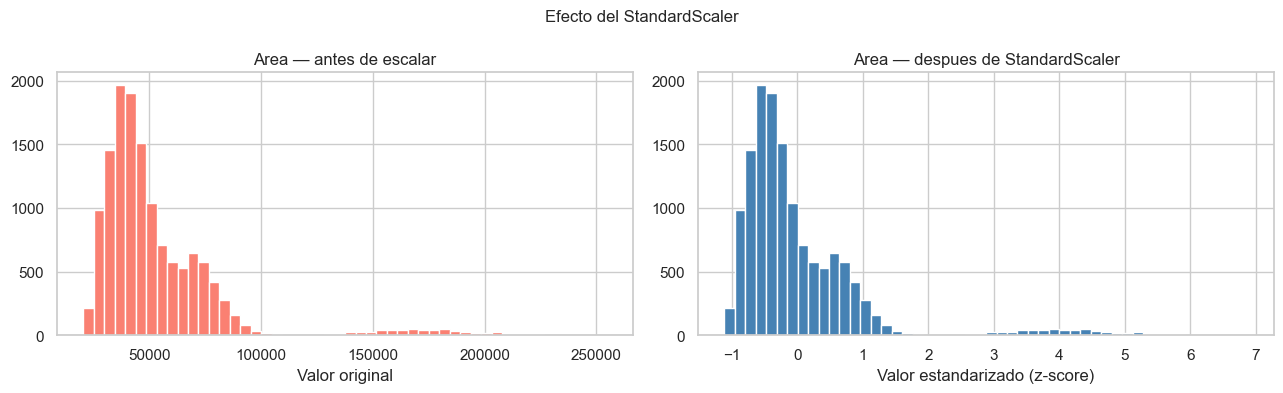

In [10]:
# Comparar distribuciones antes y despues del escalado (Area como ejemplo)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(X[:, 0], bins=50, color='salmon', edgecolor='white')
axes[0].set_title('Area — antes de escalar')
axes[0].set_xlabel('Valor original')

axes[1].hist(X_scaled[:, 0], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Area — despues de StandardScaler')
axes[1].set_xlabel('Valor estandarizado (z-score)')

plt.suptitle('Efecto del StandardScaler', fontsize=12)
plt.tight_layout()
plt.savefig('scaling_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Configuracion del escenario de etiquetado parcial

Para simular el aprendizaje semi-supervisado:
- Se divide el dataset en 80% entrenamiento / 20% prueba.
- Del conjunto de entrenamiento, solo el **10%** tendra etiqueta visible.
- El 90% restante se tratara como no etiquetado (se marca con `-1`,
  convencion requerida por scikit-learn para semi-supervisado).
  puedan reutilizar exactamente la misma particion.

In [11]:
# Split train / test (estratificado para mantener balance de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Tamanio train: {X_train.shape[0]} muestras')
print(f'Tamanio test:  {X_test.shape[0]} muestras')

Tamanio train: 10888 muestras
Tamanio test:  2723 muestras


In [12]:
# Evaluar multiples proporciones de etiquetado
LABELED_RATIO = 0.10   # <-- cambiar a 0.05, 0.10 o 0.20 para experimentar
np.random.seed(42)

n_labeled = int(len(X_train) * LABELED_RATIO)
labeled_idx = np.random.choice(len(X_train), n_labeled, replace=False)
unlabeled_idx = np.setdiff1d(np.arange(len(X_train)), labeled_idx)

# y con -1 en posiciones no etiquetadas (formato sklearn semi-supervisado)
y_train_ssl = np.full(len(X_train), -1, dtype=int)
y_train_ssl[labeled_idx] = y_train[labeled_idx]

print(f'Porcentaje etiquetado: {LABELED_RATIO*100:.0f}%')
print(f'Muestras etiquetadas:   {n_labeled}')
print(f'Muestras no etiquetadas: {len(unlabeled_idx)}')

# Verificar balance de clases en el subconjunto etiquetado
labeled_classes, labeled_counts = np.unique(y_train[labeled_idx], return_counts=True)
print('\nDistribucion en datos etiquetados:')
for cls, cnt in zip(le.classes_[labeled_classes], labeled_counts):
    print(f'  {cls}: {cnt}')

Porcentaje etiquetado: 10%
Muestras etiquetadas:   1088
Muestras no etiquetadas: 9800

Distribucion en datos etiquetados:
  BARBUNYA: 106
  BOMBAY: 45
  CALI: 126
  DERMASON: 292
  HOROZ: 170
  SEKER: 154
  SIRA: 195


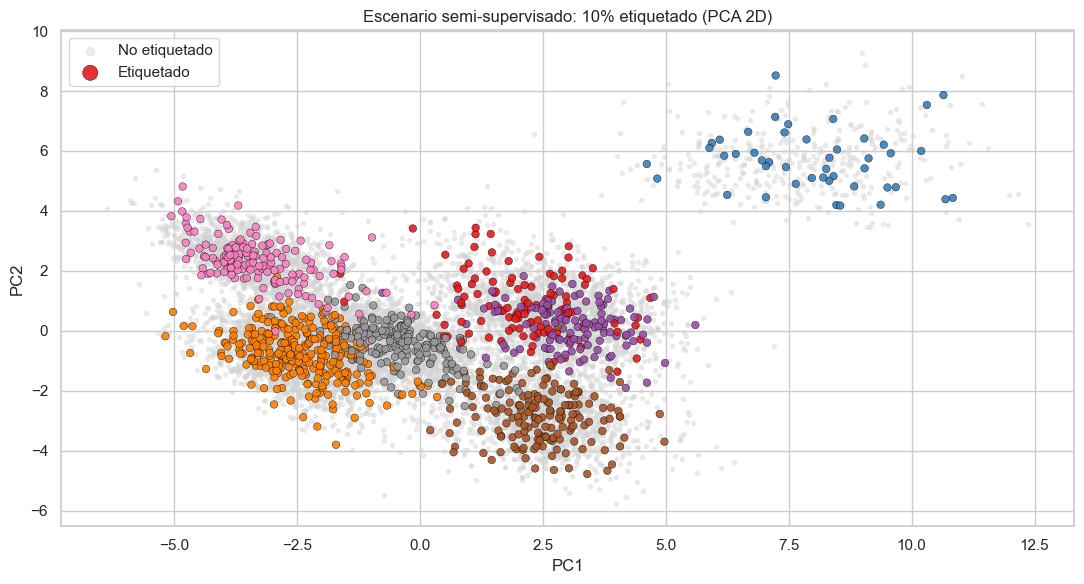

In [13]:
# Grafico comparativo: datos etiquetados vs no etiquetados en espacio PCA
pca_train = PCA(n_components=2).fit_transform(X_train)

plt.figure(figsize=(11, 6))
plt.scatter(pca_train[unlabeled_idx, 0], pca_train[unlabeled_idx, 1],
            c='lightgray', s=8, alpha=0.4, label='No etiquetado')
plt.scatter(pca_train[labeled_idx, 0], pca_train[labeled_idx, 1],
            c=y_train[labeled_idx], cmap='Set1', s=30, alpha=0.9,
            edgecolors='black', linewidths=0.3, label='Etiquetado')
plt.title(f'Escenario semi-supervisado: {LABELED_RATIO*100:.0f}% etiquetado (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(markerscale=2)
plt.tight_layout()
plt.savefig('semi_supervised_split_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Clasificador de referencia supervisado

El modelo baseline se entrena **unicamente con el subconjunto etiquetado** (10% del train),
sin aprovechar los datos no etiquetados. Sirve como punto de comparacion para medir
cuanto mejoran los algoritmos semi-supervisados al explotar los datos sin etiqueta.

In [14]:
# Entrenar Random Forest solo con las muestras etiquetadas
X_labeled = X_train[labeled_idx]
y_labeled = y_train[labeled_idx]

baseline = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
baseline.fit(X_labeled, y_labeled)

y_pred_baseline = baseline.predict(X_test)

acc = accuracy_score(y_test, y_pred_baseline)
f1  = f1_score(y_test, y_pred_baseline, average='weighted')
rec = recall_score(y_test, y_pred_baseline, average='weighted')

print('=== BASELINE SUPERVISADO (10% datos etiquetados) ===')
print(f'Accuracy : {acc:.4f}')
print(f'F1-score : {f1:.4f}')
print(f'Recall   : {rec:.4f}')
print()
print(classification_report(y_test, y_pred_baseline, target_names=le.classes_))

=== BASELINE SUPERVISADO (10% datos etiquetados) ===
Accuracy : 0.9100
F1-score : 0.9103
Recall   : 0.9100

              precision    recall  f1-score   support

    BARBUNYA       0.94      0.86      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.93      0.92       326
    DERMASON       0.90      0.92      0.91       709
       HOROZ       0.96      0.93      0.95       386
       SEKER       0.94      0.94      0.94       406
        SIRA       0.83      0.86      0.84       527

    accuracy                           0.91      2723
   macro avg       0.93      0.92      0.92      2723
weighted avg       0.91      0.91      0.91      2723



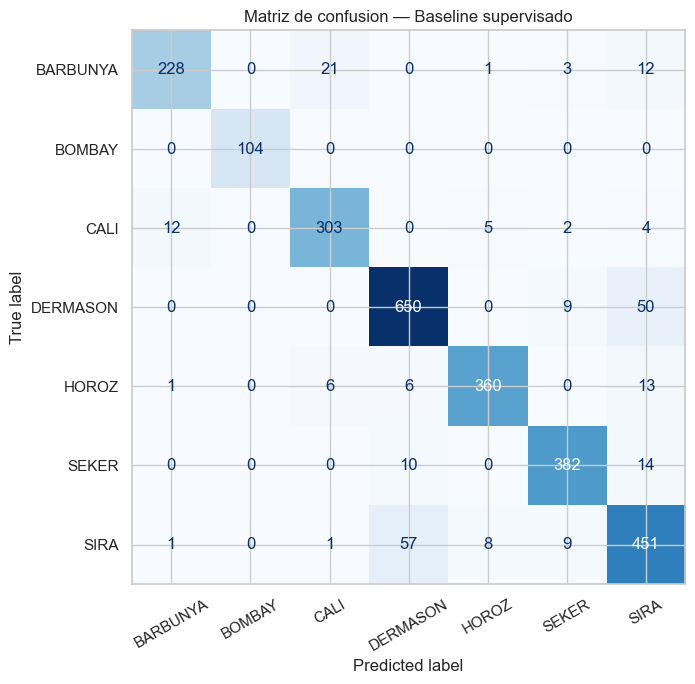

In [15]:
# Matriz de confusion del baseline
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_baseline),
    display_labels=le.classes_
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusion — Baseline supervisado', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\jfmar\AppData\Local\Temp\ipykernel_13176\1013065831.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='viridis')


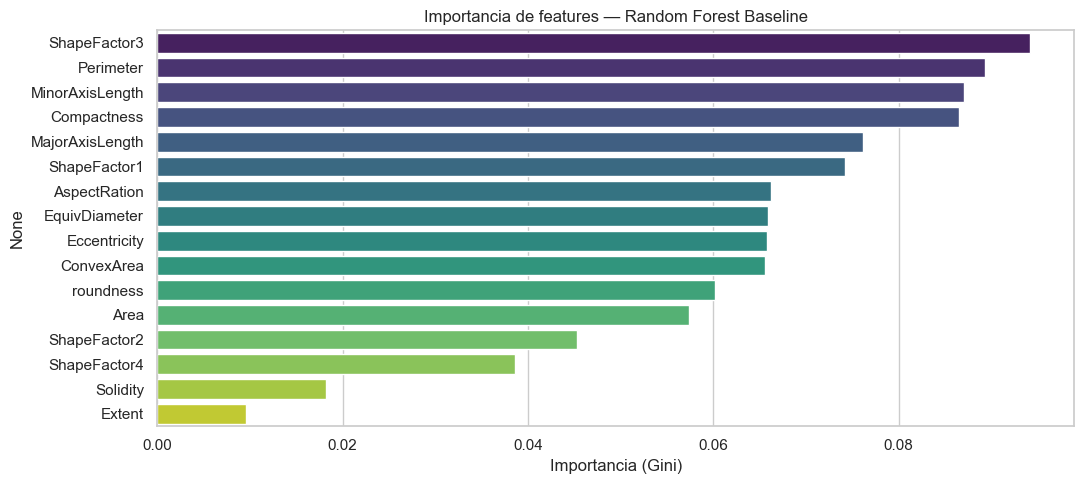

Top 5 features mas importantes:
ShapeFactor3       0.094199
Perimeter          0.089262
MinorAxisLength    0.086998
Compactness        0.086504
MajorAxisLength    0.076155
dtype: float64


In [16]:
# Importancia de features en el baseline
feat_importance = pd.Series(
    baseline.feature_importances_,
    index=df.drop(columns=['Class']).columns
).sort_values(ascending=False)

plt.figure(figsize=(11, 5))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='viridis')
plt.title('Importancia de features — Random Forest Baseline')
plt.xlabel('Importancia (Gini)')
plt.tight_layout()
plt.savefig('feature_importance_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features mas importantes:')
print(feat_importance.head())

5% etiquetado -> Accuracy: 0.9045
10% etiquetado -> Accuracy: 0.9100
15% etiquetado -> Accuracy: 0.9119
20% etiquetado -> Accuracy: 0.9137


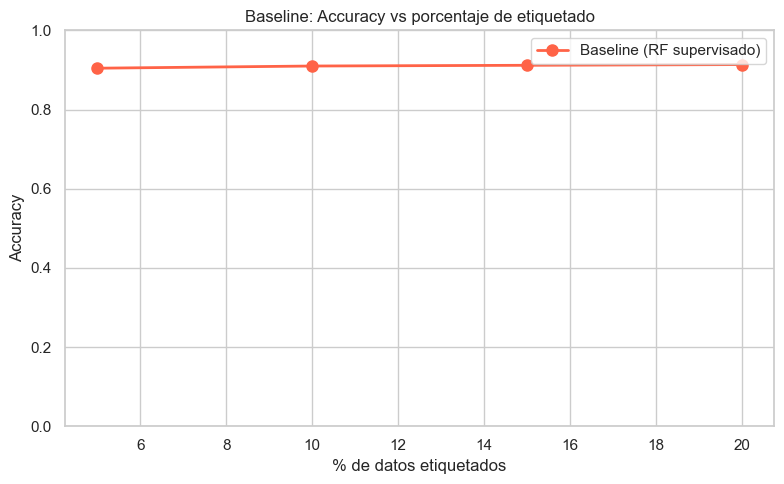

In [17]:
# Desempeno del baseline segun % de datos etiquetados
ratios = [0.05, 0.10, 0.15, 0.20]
baseline_accs = []

for r in ratios:
    n = int(len(X_train) * r)
    idx = np.random.RandomState(42).choice(len(X_train), n, replace=False)
    clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    clf.fit(X_train[idx], y_train[idx])
    baseline_accs.append(accuracy_score(y_test, clf.predict(X_test)))
    print(f'{r*100:.0f}% etiquetado -> Accuracy: {baseline_accs[-1]:.4f}')

plt.figure(figsize=(8, 5))
plt.plot([r*100 for r in ratios], baseline_accs, marker='o',
         color='tomato', linewidth=2, markersize=8, label='Baseline (RF supervisado)')
plt.xlabel('% de datos etiquetados')
plt.ylabel('Accuracy')
plt.title('Baseline: Accuracy vs porcentaje de etiquetado')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('baseline_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
import pickle

shared = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'y_train_ssl': y_train_ssl,
    'labeled_idx': labeled_idx,
    'unlabeled_idx': unlabeled_idx,
    'le': le,
    'y_pred_baseline': y_pred_baseline,
    'baseline_accs': baseline_accs,
    'ratios': ratios,
    'LABELED_RATIO': LABELED_RATIO
}

with open('shared_data.pkl', 'wb') as f:
    pickle.dump(shared, f)

print('Datos guardados en shared_data.pkl')


Datos guardados en shared_data.pkl


---
## 6. Self-Training con SVM

Implementacion del algoritmo de aprendizaje semi-supervisado **Self-Training** usando `SVC` como clasificador base. El modelo itera asignando pseudo-etiquetas a los datos no etiquetados con mayor confianza, ampliando progresivamente el conjunto de entrenamiento.

In [19]:
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix

# Clasificador base SVC con kernel RBF
base_clf = SVC(kernel='rbf', probability=True, random_state=42)

# Self-Training con umbral de confianza 0.75
self_training = SelfTrainingClassifier(estimator=base_clf, threshold=0.75, max_iter=10)
self_training.fit(X_train, y_train_ssl)

y_pred_st = self_training.predict(X_test)

print('=== SELF-TRAINING (threshold=0.75, kernel=rbf) ===')
print(classification_report(y_test, y_pred_st, target_names=le.classes_))

=== SELF-TRAINING (threshold=0.75, kernel=rbf) ===
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.88      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.95      0.94       326
    DERMASON       0.91      0.91      0.91       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.94      0.94       406
        SIRA       0.85      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



Threshold 0.5: Accuracy = 0.9196
Threshold 0.6: Accuracy = 0.9177
Threshold 0.75: Accuracy = 0.9199
Threshold 0.85: Accuracy = 0.9181
Threshold 0.95: Accuracy = 0.9159


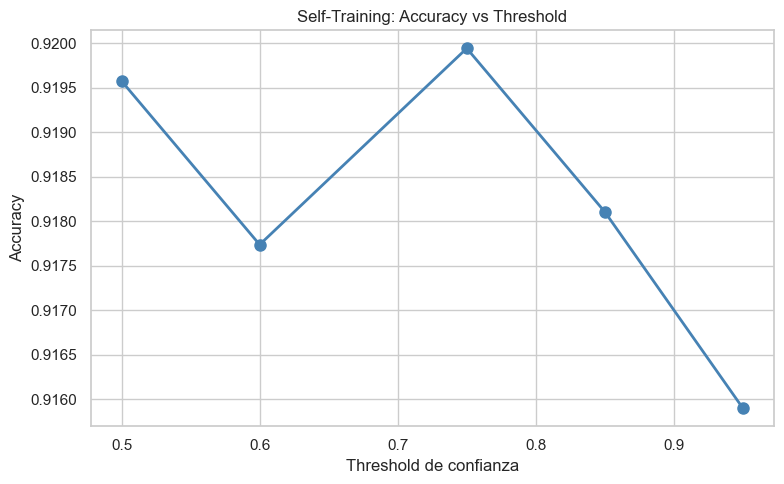

In [20]:
# Sensibilidad al umbral de confianza
thresholds = [0.5, 0.6, 0.75, 0.85, 0.95]
resultados_threshold = []

for t in thresholds:
    clf = SelfTrainingClassifier(
        estimator=SVC(kernel='rbf', probability=True, random_state=42),
        threshold=t, max_iter=10
    )
    clf.fit(X_train, y_train_ssl)
    acc = accuracy_score(y_test, clf.predict(X_test))
    resultados_threshold.append(acc)
    print(f'Threshold {t}: Accuracy = {acc:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(thresholds, resultados_threshold, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('Threshold de confianza')
plt.ylabel('Accuracy')
plt.title('Self-Training: Accuracy vs Threshold')
plt.grid(True)
plt.tight_layout()
plt.savefig('Results/self_training_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

Kernel 'linear': Accuracy = 0.9221
Kernel 'rbf': Accuracy = 0.9199
Kernel 'poly': Accuracy = 0.8884


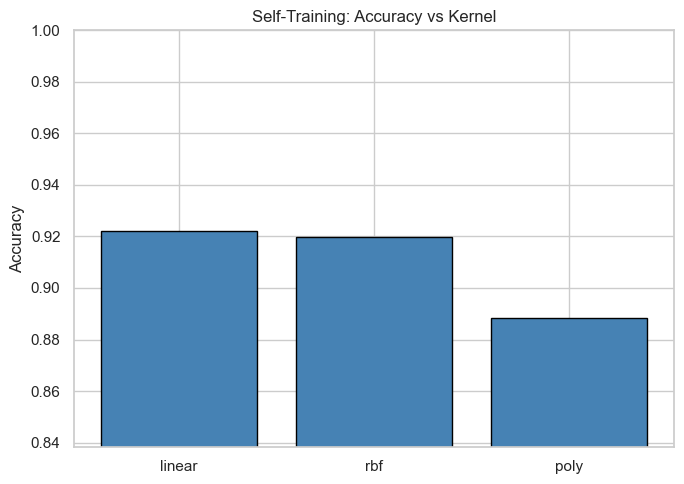

In [21]:
# Efecto del tipo de kernel en el clasificador base
kernels = ['linear', 'rbf', 'poly']
resultados_kernel = []

for k in kernels:
    clf = SelfTrainingClassifier(
        estimator=SVC(kernel=k, probability=True, random_state=42),
        threshold=0.75, max_iter=10
    )
    clf.fit(X_train, y_train_ssl)
    acc = accuracy_score(y_test, clf.predict(X_test))
    resultados_kernel.append(acc)
    print(f"Kernel '{k}': Accuracy = {acc:.4f}")

plt.figure(figsize=(7, 5))
plt.bar(kernels, resultados_kernel, color='steelblue', edgecolor='black')
plt.ylabel('Accuracy')
plt.title('Self-Training: Accuracy vs Kernel')
plt.ylim(min(resultados_kernel) - 0.05, 1.0)
plt.tight_layout()
plt.savefig('Results/self_training_kernel.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Impacto del volumen de etiquetas en el rendimiento
ratios_st = [0.05, 0.10, 0.15, 0.20]
acc_por_ratio = []

for ratio in ratios_st:
    n = int(len(X_train) * ratio)
    idx = np.random.RandomState(42).choice(len(X_train), n, replace=False)

    y_ssl = np.full(len(X_train), -1, dtype=int)
    y_ssl[idx] = y_train[idx]

    clf = SelfTrainingClassifier(
        estimator=SVC(kernel='rbf', probability=True, random_state=42),
        threshold=0.75, max_iter=10
    )
    clf.fit(X_train, y_ssl)
    acc_por_ratio.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot([r*100 for r in ratios_st], acc_por_ratio, marker='o',
         color='steelblue', linewidth=2, markersize=8, label='Self-Training')
plt.plot([r*100 for r in ratios], baseline_accs, marker='s',
         color='tomato', linewidth=2, markersize=8, linestyle='--', label='Baseline (RF supervisado)')
plt.xlabel('% de datos etiquetados')
plt.ylabel('Accuracy')
plt.title('Desempeno vs % de etiquetas — Self-Training vs Baseline')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('Results/self_training_label_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Evaluacion final del Self-Training con el mejor umbral
best_st = SelfTrainingClassifier(
    estimator=SVC(kernel='rbf', probability=True, random_state=42),
    threshold=0.75, max_iter=10
)
best_st.fit(X_train, y_train_ssl)
y_pred_st_final = best_st.predict(X_test)

acc_st = accuracy_score(y_test, y_pred_st_final)
f1_st  = f1_score(y_test, y_pred_st_final, average='weighted')
rec_st = recall_score(y_test, y_pred_st_final, average='weighted')

print('=== SELF-TRAINING — Metricas finales ===')
print(f'Accuracy : {acc_st:.4f}')
print(f'F1-score : {f1_st:.4f}')
print(f'Recall   : {rec_st:.4f}')

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    confusion_matrix(y_test, y_pred_st_final),
    annot=True, fmt='d', cmap='Greens',
    xticklabels=le.classes_, yticklabels=le.classes_, ax=ax
)
ax.set_title('Matriz de Confusion — Self-Training', fontsize=12)
ax.set_xlabel('Prediccion')
ax.set_ylabel('Real')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('Results/confusion_matrix_self_training.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Resumen comparativo: Baseline vs Self-Training
acc_base = accuracy_score(y_test, y_pred_baseline)
f1_base  = f1_score(y_test, y_pred_baseline, average='weighted')
rec_base = recall_score(y_test, y_pred_baseline, average='weighted')

print('=' * 48)
print(f"{'Modelo':<32} {'Accuracy':>8}  {'F1':>6}  {'Recall':>7}")
print('=' * 48)
print(f"{'Baseline (RF, 10% etiquetado)':<32} {acc_base:>8.4f}  {f1_base:>6.4f}  {rec_base:>7.4f}")
print(f"{'Self-Training (SVC rbf, t=0.75)':<32} {acc_st:>8.4f}  {f1_st:>6.4f}  {rec_st:>7.4f}")
print('=' * 48)

---
## 7. Label Propagation y Label Spreading

Algoritmos semi-supervisados basados en grafos que propagan etiquetas a traves de la estructura de similitud entre muestras (kernel RBF).

In [ ]:
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix

# Label Propagation con kernel RBF
lp = LabelPropagation(kernel='rbf', gamma=20, max_iter=1000)
lp.fit(X_train, y_train_ssl)

y_pred_lp = lp.predict(X_test)

print('=== LABEL PROPAGATION ===')
print(classification_report(y_test, y_pred_lp, target_names=le.classes_))

In [ ]:
# Label Spreading (version mas robusta con parametro alpha)
ls = LabelSpreading(kernel='rbf', gamma=20, alpha=0.2, max_iter=1000)
ls.fit(X_train, y_train_ssl)

y_pred_ls = ls.predict(X_test)

print('=== LABEL SPREADING ===')
print(classification_report(y_test, y_pred_ls, target_names=le.classes_))

In [ ]:
# Sensibilidad al radio y tipo de conexion del grafo
gammas = [0.1, 1, 5, 20, 50]
resultados_gamma = []

for g in gammas:
    clf = LabelSpreading(kernel='rbf', gamma=g, alpha=0.2, max_iter=1000)
    clf.fit(X_train, y_train_ssl)
    acc = accuracy_score(y_test, clf.predict(X_test))
    resultados_gamma.append(acc)
    print(f'Gamma {g}: Accuracy = {acc:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(gammas, resultados_gamma, marker='o', color='darkorange', linewidth=2, markersize=8)
plt.xlabel('Gamma')
plt.ylabel('Accuracy')
plt.title('Label Spreading: Accuracy vs Gamma')
plt.grid(True)
plt.tight_layout()
plt.savefig('Results/label_spreading_gamma.png', dpi=150, bbox_inches='tight')
plt.show()

# Comparar kernels
for k in ['rbf', 'knn']:
    clf = LabelSpreading(kernel=k, max_iter=1000)
    clf.fit(X_train, y_train_ssl)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f'Kernel {k}: Accuracy = {acc:.4f}')

In [ ]:
# Efecto del factor de amortiguamiento
alphas = [0.1, 0.2, 0.4, 0.6, 0.8]
resultados_alpha = []

for a in alphas:
    clf = LabelSpreading(kernel='rbf', gamma=20, alpha=a, max_iter=1000)
    clf.fit(X_train, y_train_ssl)
    acc = accuracy_score(y_test, clf.predict(X_test))
    resultados_alpha.append(acc)
    print(f'Alpha {a}: Accuracy = {acc:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(alphas, resultados_alpha, marker='s', color='purple', linewidth=2, markersize=8)
plt.xlabel('Alpha')
plt.ylabel('Accuracy')
plt.title('Label Spreading: Accuracy vs Alpha')
plt.grid(True)
plt.tight_layout()
plt.savefig('Results/label_spreading_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Rendimiento segun cobertura de etiquetado
ratios_lp = [0.05, 0.10, 0.15, 0.20]
acc_lp = []
acc_ls = []

for ratio in ratios_lp:
    n = int(len(X_train) * ratio)
    idx = np.random.RandomState(42).choice(len(X_train), n, replace=False)

    y_ssl = np.full(len(X_train), -1, dtype=int)
    y_ssl[idx] = y_train[idx]

    clf_lp = LabelPropagation(kernel='rbf', gamma=20, max_iter=1000)
    clf_lp.fit(X_train, y_ssl)
    acc_lp.append(accuracy_score(y_test, clf_lp.predict(X_test)))

    clf_ls = LabelSpreading(kernel='rbf', gamma=20, alpha=0.2, max_iter=1000)
    clf_ls.fit(X_train, y_ssl)
    acc_ls.append(accuracy_score(y_test, clf_ls.predict(X_test)))

x = [r * 100 for r in ratios_lp]
plt.figure(figsize=(9, 5))
plt.plot(x, acc_lp, marker='o', label='Label Propagation', linewidth=2, markersize=8)
plt.plot(x, acc_ls, marker='s', label='Label Spreading', linewidth=2, markersize=8)
plt.xlabel('% de datos etiquetados')
plt.ylabel('Accuracy')
plt.title('Desempeno vs % de etiquetas')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('Results/label_graph_label_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Contraste entre enfoques de aprendizaje
resultados = {
    'Modelo': ['Baseline (RF)', 'Self-Training', 'Label Propagation', 'Label Spreading'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_st),
        accuracy_score(y_test, y_pred_lp),
        accuracy_score(y_test, y_pred_ls),
    ],
    'F1-score': [
        f1_score(y_test, y_pred_baseline, average='weighted'),
        f1_score(y_test, y_pred_st, average='weighted'),
        f1_score(y_test, y_pred_lp, average='weighted'),
        f1_score(y_test, y_pred_ls, average='weighted'),
    ],
    'Recall': [
        recall_score(y_test, y_pred_baseline, average='weighted'),
        recall_score(y_test, y_pred_st, average='weighted'),
        recall_score(y_test, y_pred_lp, average='weighted'),
        recall_score(y_test, y_pred_ls, average='weighted'),
    ]
}

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

In [ ]:
# Analisis visual de errores y predicciones (Label Spreading)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    confusion_matrix(y_test, y_pred_ls),
    annot=True, fmt='d', cmap='Oranges',
    xticklabels=le.classes_, yticklabels=le.classes_, ax=ax
)
ax.set_title('Matriz de Confusion — Label Spreading', fontsize=12)
ax.set_xlabel('Prediccion')
ax.set_ylabel('Real')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('Results/confusion_matrix_label_spreading.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y_test[:50], label='Real', marker='o')
plt.plot(y_pred_ls[:50], label='Prediccion', marker='x')
plt.title('Prediccion vs Real — Label Spreading (primeros 50 ejemplos)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('Results/prediction_vs_real_label_spreading.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Reflexiones finales (informe PDF)

**Mejor modelo:** Comparar la tabla de metricas (`df_resultados`). Indicar cual obtuvo mayor Accuracy, F1 y Recall, y relacionarlo con la naturaleza del dataset (7 clases morfologicas, alta dimensionalidad, separabilidad en PCA).

**Efecto del % etiquetado:** Analizar las curvas de Label Propagation vs Label Spreading y contrastarlas con Baseline y Self-Training. Describir si el beneficio semi-supervisado crece al aumentar etiquetas.

**Self-Training vs Label Propagation/Spreading:**
- *Self-Training:* iterativo, depende del clasificador base (SVM) y del umbral de confianza; riesgo de confirmar errores en pseudo-etiquetas.
- *Grafos (LP/LS):* explotan similitud global; sensibles a `gamma` (radio del grafo) y `alpha` (amortiguamiento); no requieren umbral pero el costo computacional crece con N.

**Sobreajuste/subajuste:** Revisar matrices de confusion — clases confundidas recurrentemente (ej. variedades morfologicamente similares). Comparar train vs test si se observan discrepancias fuertes entre modelos.

**Escenario real con pocos etiquetados:** En produccion agricola/industrial, etiquetar granos es costoso; los metodos de grafo pueden aprovechar estructura local, pero requieren features bien escaladas y tuning de hiperparametros. Self-Training es mas interpretable pero inestable con pocos seeds iniciales.